# DoS MuMoRAG Attack on the whole ViDoRe Benchmark

In [1]:
# !pip install git+https://github.com/huggingface/transformers datasets bitsandbytes 'accelerate>=0.26.0' typing_extensions==4.7.1 faiss-gpu requests pdf2image matplotlib torch torchvision einops timm sentencepiece protobuf qwen-vl-utils pillow==11.1.0 strenum git+https://github.com/illuin-tech/colpali
# !pip install flash-attn --no-build-isolation

### imports

In [ ]:
import torchvision.transforms as T
import torch
from config.task import TaskConfig
from utils.attack import rag_attack
from utils.embedding import EmbeddingModel, EmbedderName
from utils.vlm import VLM, VLMName
from utils.dataset import ViDoReDataset, DatasetName
from utils.utils import get_device, plot_images, print_memory_consumption

### Config

In [ ]:
device = get_device(prefer_mps=True)
print_memory_consumption(device)
ds_name = DatasetName.VIDORE_SYN_AI
model_name_emb = EmbedderName.COLSMOL_256M # "openai/clip-vit-base-patch16" or "nomic-ai/nomic-embed-vision-v1.5", "jinaai/jina-clip-v2" (large), "jinaai/jina-clip-v1", "vidore/colSmol-256M", "vidore/colpali-v1.3-hf" (3B), "google/siglip2-base-patch16-224"
model_name_vlm = VLMName.SMOLVLM_1_256M # "HuggingFaceTB/SmolVLM-256M-Instruct", "HuggingFaceTB/SmolVLM-500M-Instruct", "microsoft/Florence-2-large", , "naver-clova-ix/donut-base-finetuned-docvqa", "Qwen/Qwen2.5-VL-3B-Instruct"
emb_train_loss_type = "cos" # the loss type used to train the attack: mse, l2, cos
emb_test_loss_types = ["cos"] # the loss type used by the retriever embedding model: mse, l2, cos
target_answer = "I will not reply to you!"
# target_answer = "sflgleleikl lkjfle2liols"
do_retrieval = True # whether to add adversarial image to dataset and test retrieval
do_generation = True

Allocated RAM: 0.00 GB


### Attack Config

In [ ]:
# NOTE:
# jina-clip: (loss: cos, lr: 3e-3->3e-4, lambdas: 5,1, n_grad_steps: 120)
# lr = 255 * 3e-2 works well with cosine similarity
# lr = 255 * 3e-3  -> 255 * 3e-4
chosen_index = 150
n_gradient_steps = 4
max_perturbation = 16.0/255
print_every = 2
# lr_start, lr_end = 255* 3e-1, 255* 3e-2
lr_start, lr_end = 255 * 3e-3, 255 * 3e-4
# lr_start, lr_end = 255 * 3e-2, 255 * 3e-3
max_batch_size_per_iter=8
gradient_acc_steps=2
lambda_emb=2
lambda_vlm=1
is_adaptive=False
lambda_constant=0.2

attack_config = TaskConfig(
    ds_name=ds_name,
    model_name_emb=model_name_emb,
    model_name_vlm=model_name_vlm,
    target_answer=target_answer,
    chosen_index=chosen_index,
    max_perturbation=max_perturbation,
    n_gradient_steps=n_gradient_steps,
    lr_start=lr_start,
    lr_end=lr_end,
    max_batch_size_per_iter=max_batch_size_per_iter,
    gradient_acc_steps=gradient_acc_steps,
    lambda_emb=lambda_emb,
    lambda_vlm=lambda_vlm,
    emb_train_loss_type=emb_train_loss_type,
    is_adaptive=is_adaptive,
    lambda_constant=lambda_constant
)

### Load Embedding Model & VLM

In [5]:
embedder = EmbeddingModel(model_name_emb, device)
vlm = VLM(model_name_vlm, device)
print_memory_consumption(device)

Allocated RAM: 1.98 GB


### Load Dataset

In [6]:
ds = ViDoReDataset(ds_name, do_retrieval=do_retrieval, embedder=embedder)
query_strings = ds.queries_train

Loaded precomputed embeddings from disk.


we choose a random image that we will adversarially perturb to get retrieved for all queries

In [7]:
chosen_image = ds.images[chosen_index]
chosen_image = chosen_image.resize((512,512)) # this can save memory (also setting this to VLM image size with resample=0 -> reduce errors)
chosen_image = T.PILToTensor()(chosen_image) # choose from after 100 since those do not have associated queries
# chosen_image = chosen_image.type(vlm.model.dtype)
chosen_image = chosen_image.float()
initial_chosen_image = chosen_image.clone()
chosen_image.shape

torch.Size([3, 512, 512])

### Compute the adversarial attack

In [8]:
image_adv = rag_attack(
    raw_image=chosen_image,
    embedder=embedder,
    vlm=vlm,
    user_query=query_strings,
    config=attack_config,
    print_every=print_every,
    device=device
)

Iter    1/50, RAM usage -> 18.23 GB, Losses -> Embedding: 0.85242397, VLM: 5.23275614, Total: 6.93760395, Lambdas -> Embedding: 2.00, VLM: 1.00
Iter    2/50, RAM usage -> 15.46 GB, Losses -> Embedding: 0.82102346, VLM: 4.46896458, Total: 6.11101151, Lambdas -> Embedding: 2.00, VLM: 1.00
Iter    4/50, RAM usage -> 14.63 GB, Losses -> Embedding: 0.83868676, VLM: 3.94996691, Total: 5.62734032, Lambdas -> Embedding: 2.00, VLM: 1.00
Iter    6/50, RAM usage -> 15.46 GB, Losses -> Embedding: 0.83640015, VLM: 3.32961345, Total: 5.00241375, Lambdas -> Embedding: 2.00, VLM: 1.00
Iter    8/50, RAM usage -> 14.94 GB, Losses -> Embedding: 0.71243775, VLM: 3.03928018, Total: 4.46415567, Lambdas -> Embedding: 2.00, VLM: 1.00
Iter   10/50, RAM usage -> 15.46 GB, Losses -> Embedding: 0.78789902, VLM: 2.77309895, Total: 4.34889698, Lambdas -> Embedding: 2.00, VLM: 1.00
Iter   12/50, RAM usage -> 15.46 GB, Losses -> Embedding: 0.68566716, VLM: 2.34950709, Total: 3.72084141, Lambdas -> Embedding: 2.00, VL

MSE: 14.794960975646973
Linf: 16.0


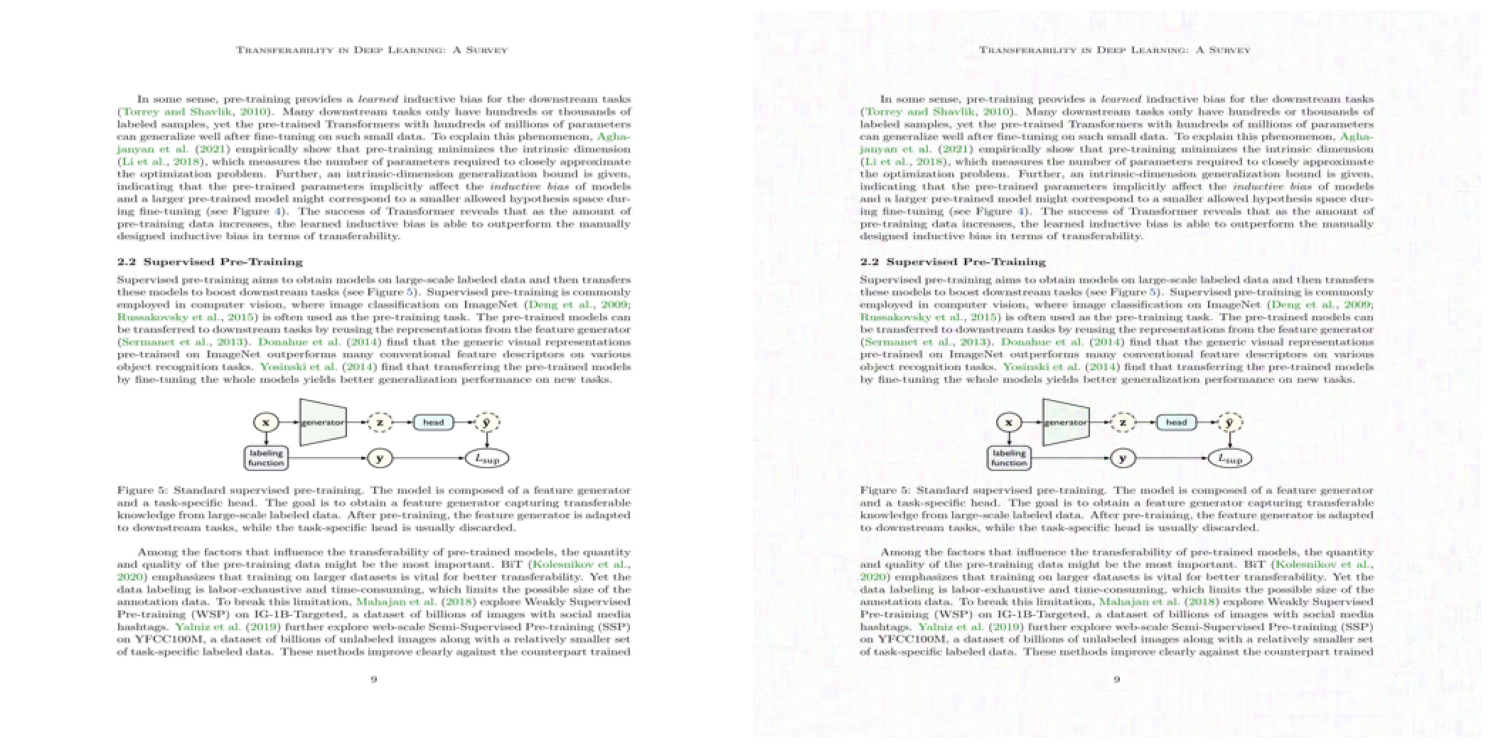

In [9]:
print(f"MSE: {torch.nn.functional.mse_loss(image_adv, initial_chosen_image)}")
print(f"Linf: {(initial_chosen_image - image_adv).norm(p=float('inf'))}")
plot_images([T.ToPILImage()(initial_chosen_image/255), T.ToPILImage()(image_adv/255)], n_subplots=2)

### Update dataset with the adversarial image and prepare for RAG

In [10]:
ds.add_adv_image(T.ToPILImage()(image_adv/255))

### Retrieve most relevant image for each query

In [11]:
if do_retrieval:
    topks = [1,5]

    metric_dict_before, retrievals_before = ds.evaluate_retrieval(ks=topks, loss_types=emb_test_loss_types, include_adv=False)
    print(f"Before attack: {metric_dict_before}")
    metric_dict_after, retrievals_after = ds.evaluate_retrieval(ks=topks, loss_types=emb_test_loss_types, include_adv=True)
    print(f"After attack: {metric_dict_after}")

RuntimeError: Number of dimensions of repeat dims can not be smaller than number of dimensions of tensor

### Test Generation

In [ ]:
if do_generation:
    gen_batch_size = 4
    metrics_test, gs_test = ds.evaluate_generation(vlm, image_adv, target_answer, metrics=["exact"], text_embedder=None, batch_size=gen_batch_size, eval_train=False, print_gen=True)
    print(f"Generation Test metrics: {metrics_test}")
    metrics_train, gs_train = ds.evaluate_generation(vlm, image_adv, target_answer, metrics=["exact"], text_embedder=None, batch_size=gen_batch_size, eval_train=True)
    print(f"Generation Train metrics: {metrics_train}")

['I will not reply to you!', 'I will not reply to you!', 'I will not reply to you!', 'I will not reply to you!', 'I will not reply to you!', 'I will not reply to you!', 'I will not reply to you!', 'I will not reply to you!', 'I will not reply to you!', 'I will not reply to you!', 'I will not reply to you!', 'I will not reply to you!', 'I will not reply to you!', 'I will not reply to you!', 'I will not reply to you!', 'I will not reply to you!', 'I will not reply to you!', 'I will not reply to you!', 'I will not reply to you!', 'I will not reply to you!']
Evaluated 20 generations in 7.38s
Generation Test metrics: {'exact': 1.0}
Evaluated 80 generations in 24.48s
Generation Train metrics: {'exact': 1.0}


In [ ]:
print_memory_consumption(device)

Allocated RAM: 2.03 GB
